# Assignment 1 — Working with Open Data

In this assignment you take a **real, public dataset**, ask questions of it, answer them, and document your work so that someone else could reproduce it.

**A few things to know before you start:**
- This course is about **data, not code.** The point of A1 is the analytical questions and what the numbers tell you about how people behave — *not* whether you remember Python syntax.
- You can do the analysis **in Python here, or in Google Sheets.** Every question below works either way. Pick whatever lets you think about the data instead of fighting the tool.
- You may use an **AI assistant** (ChatGPT, Claude, …) to help you write code — with rules. See *A note on using AI* at the bottom before you do.

**What you'll turn in** (committed to your `hcde-410` repo):
1. This notebook, with your answers filled in.
2. A short **README.md** describing your work.
3. A **LICENSE** file, and a note about the dataset's own license.

Your commit history is part of the record — commit as you go.

## Part 0 — Get the data

The data comes from [data.seattle.gov](https://data.seattle.gov/), the City of Seattle's open-data portal. We'll use the [Burke-Gilman Trail counter north of NE 70th St](https://data.seattle.gov/Transportation/Burke-Gilman-Trail-north-of-NE-70th-St-Bicycle-and/2z5v-ecg8), which records **bike and pedestrian traffic, by hour, by direction**.

We'll pull the data straight from the city's API rather than downloading a file by hand. That's a small reproducibility win: anyone who runs this notebook gets the same data the same way, and it's written down exactly where it came from.

In [41]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

In [42]:
# The dataset's API endpoint, and a query for one year of data (2019).
# You can paste the full URL into a browser to preview the raw data.
api_endpoint = "https://data.seattle.gov/resource/2z5v-ecg8.json?"
api_parameters = "$limit=50000&$where=date > '2019-01-01T00:00:00' AND date < '2020-01-01T00:00:00'"

response = requests.get(api_endpoint + api_parameters)
raw_data = response.json()
print("Downloaded", len(raw_data), "hourly records.")
# If this cell fails (e.g. the API is down), see the note below the next cell.

Downloaded 8759 hourly records.


Now load it into a **pandas DataFrame** — a table, like a spreadsheet you can compute with.

In [6]:
df = pd.DataFrame(raw_data)
df.head()

,date,bgt_north_of_ne_70th_total,ped_south,ped_north,bike_north,bike_south
0,2019-01-01T01:00:00.000,2,1,0,1,0
1,2019-01-01T02:00:00.000,1,0,0,0,1
2,2019-01-01T03:00:00.000,0,0,0,0,0
3,2019-01-01T04:00:00.000,1,0,0,1,0
4,2019-01-01T05:00:00.000,1,0,0,1,0


### Quick sanity checks

Whenever you work with data **you didn't create**, check that it means what you think before you analyze it. Two things need fixing here:
- the counts arrive as **text**, so we convert them to numbers;
- the `date` is a string, so we convert it to a real **datetime** and pull out the hour and weekday.

We'll also add tidy `bikes` and `peds` columns (north + south).

In [43]:
# convert the count columns from text to numbers
count_cols = ["bike_north", "bike_south", "ped_north", "ped_south", "bgt_north_of_ne_70th_total"]
df[count_cols] = df[count_cols].apply(pd.to_numeric, errors="coerce")

# convert the date string to a real datetime, and derive hour + weekday
df["date"] = pd.to_datetime(df["date"])
df["hour"] = df["date"].dt.hour
df["weekday"] = df["date"].dt.day_name()

# combined bike and pedestrian counts
df["bikes"] = df["bike_north"] + df["bike_south"]
df["peds"]  = df["ped_north"] + df["ped_south"]

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8759 entries, 0 to 8758
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   date                        8759 non-null   datetime64[ns]
 1   bgt_north_of_ne_70th_total  8759 non-null   int64         
 2   ped_south                   8759 non-null   int64         
 3   ped_north                   8759 non-null   int64         
 4   bike_north                  8759 non-null   int64         
 5   bike_south                  8759 non-null   int64         
 6   hour                        8759 non-null   int32         
 7   weekday                     8759 non-null   object        
 8   bikes                       8759 non-null   int64         
 9   peds                        8759 non-null   int64         
 10  avg_users                   8759 non-null   float64       
 11  day_type                    8759 non-null   object      

,date,bgt_north_of_ne_70th_total,ped_south,ped_north,bike_north,bike_south,hour,bikes,peds,avg_users,combined_avg,north_avg,south_avg
count,8759,8759.000000,8759.000000,8759.000000,8759.000000,8759.000000,8759.000000,8759.000000,8759.000000,8759.000000,8759.000000,8759.000000,8759.000000
mean,2019-07-02 12:00:00,58.423564,8.047380,8.363169,19.875671,22.137344,11.501313,42.013015,16.410549,29.211782,29.211782,14.119420,15.092362
min,2019-01-01 01:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2019-04-02 06:30:00,2.000000,0.000000,0.000000,0.000000,1.000000,6.000000,1.000000,0.000000,1.000000,1.000000,0.500000,0.500000
50%,2019-07-02 12:00:00,33.000000,5.000000,6.000000,9.000000,8.000000,12.000000,20.000000,11.000000,16.500000,16.500000,8.000000,7.500000
75%,2019-10-01 17:30:00,91.000000,13.000000,14.000000,31.000000,30.000000,17.500000,64.000000,27.000000,45.500000,45.500000,22.500000,21.500000
max,2019-12-31 23:00:00,1764.000000,1324.000000,782.000000,199.000000,961.000000,23.000000,1039.000000,1752.000000,882.000000,882.000000,393.500000,663.500000
std,NaN,73.656910,16.882468,13.164217,26.299728,34.080707,6.921886,56.534598,27.675776,36.828455,36.828455,17.375925,21.528867


**Look at what `describe()` tells you.** Are there hours with 0 traffic? Any missing values (a sensor can go offline)? Note anything odd — you'll want to mention data limitations later.

**No-code option:** run the next cell to save the cleaned data as a CSV, then open it in Google Sheets and do your analysis there. If you go this route, title your sheet **"A1 — [your name]"**, share it so anyone with the link can view, and paste the link into your written answers.

In [ ]:
df.to_csv("bg_hourly_2019.csv", index=False)
print("Saved bg_hourly_2019.csv — a row per hour of 2019.")

## Part 1 — One worked example: when do cyclists ride?

Here is the whole technique, **once**, so you can see the pattern. After this, the questions are yours.

The move is always the same: **group → summarize → plot → interpret.** In pandas that's a couple of lines (no loops needed).

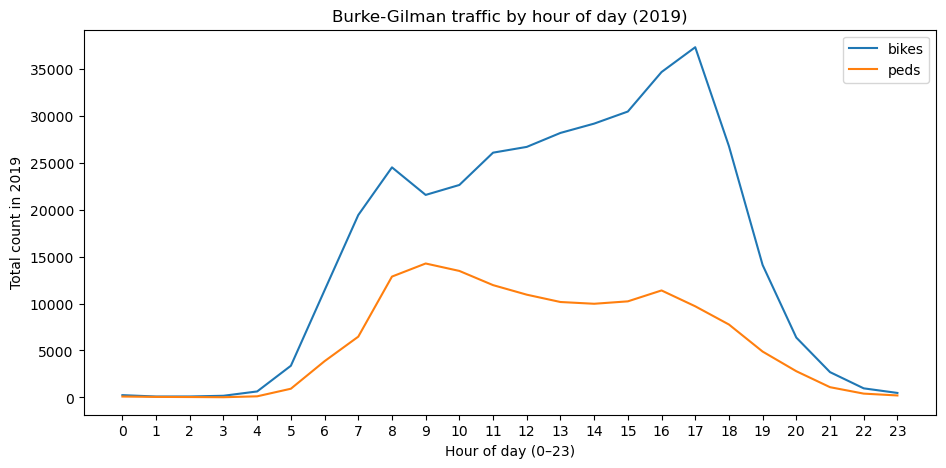

In [44]:
# group every row by its hour of day, and sum bikes and peds within each hour
by_hour = df.groupby("hour")[["bikes", "peds"]].sum()

by_hour.plot(figsize=(11, 5))
plt.title("Burke-Gilman traffic by hour of day (2019)")
plt.xlabel("Hour of day (0–23)")
plt.ylabel("Total count in 2019")
plt.xticks(range(0, 24))
plt.show()

**Now read the plot — this is the actual work.** What does the shape tell you? Do you see one peak or two? What might a double peak mean about *why* people are on the trail? That interpretation — turning a shape into a claim about human behavior — is what every question below is really asking for.

## Part 2 — Your analysis

Answer each question below. For every one:
1. **Show how you got there** — a pandas cell here, or (no-code) a link to your Google Sheet in the answer.
2. **Interpret it in 2–4 sentences** — what does this say about how people actually use the trail? The interpretation is the point, not the number.

There isn't a single right answer to most of these. Making a reasonable choice and *defending* it is the skill.

**Q1. When is the trail busiest, and when is it quietest?**
Decide what *busy* means to you first — a single hour? a stretch of the day? bikes and peds together, or separately? — and say why you chose that.

**AI USE**

Used Claude with these prompts: 
1) can I have help averaging the two things, bikes and pedestrians, at all times, and then finding when the peak is?
This did not work as it gave an average for each: bikes and peds, not a combined average.

3) okay so actually I want to create a new graph that shows the average number of users between both classes as a continuous graph

Peak hour for the combined average: 17 with an average of 64.4
Quietest hour for the combined average: 2 with an average of 0.2


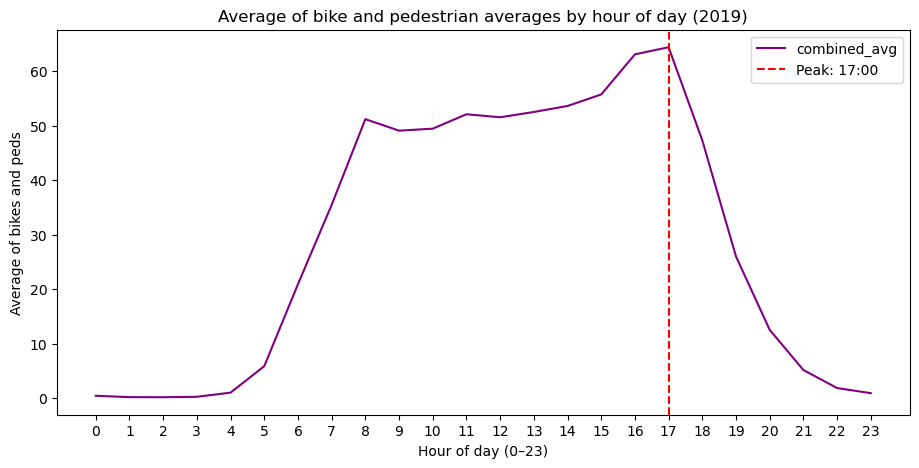

In [45]:
# average of the two hourly averages
avg_by_hour = df.groupby("hour")[["bikes", "peds"]].mean()
avg_by_hour["combined_avg"] = (avg_by_hour["bikes"] + avg_by_hour["peds"]) / 2

combined_peak_hour = avg_by_hour["combined_avg"].idxmax()
combined_peak_value = avg_by_hour["combined_avg"].max()
print("Peak hour for the combined average:", combined_peak_hour, "with an average of", round(combined_peak_value, 1))
combined_min_hour = avg_by_hour["combined_avg"].idxmin()
combined_min_value = avg_by_hour["combined_avg"].min()
print("Quietest hour for the combined average:", combined_min_hour, "with an average of", round(combined_min_value, 1))

# plot it
avg_by_hour["combined_avg"].plot(figsize=(11, 5), color="purple")
plt.axvline(combined_peak_hour, color="red", linestyle="--", label=f"Peak: {combined_peak_hour}:00")
plt.title("Average of bike and pedestrian averages by hour of day (2019)")
plt.xlabel("Hour of day (0–23)")
plt.ylabel("Average of bikes and peds")
plt.xticks(range(0, 24))
plt.legend()
plt.show()

**Your Q1 answer:**

*The trail is busiest at approximately 5pm and quietest at approximately 2 am, but it also looks like it's quite busy at around 8am. This is probably because people use the trail to get to class/work and all leave at near the same time: 5pm.*

**Q2. Do cyclists and pedestrians use the trail at different times of day?**
Compare their hourly patterns. If they differ, what might explain it?

**AI USE**

Used Claude for this with the following prompts:

1) can I have help averaging the two things, bikes and pedestrians, at all times, and then finding when the peak is?
Used the code we generated from the original prompt from Q1 (it didn't give us what we wanted for Q1, but was useful for Q2) and then we added the minimum values.

Peak hour for bikes: 17 with an average of 102.2
Peak hour for peds: 9 with an average of 39.1
Quietest hour for bikes: 1 with an average of 0.3
Quitest hour for peds: 3 with an average of 0.1


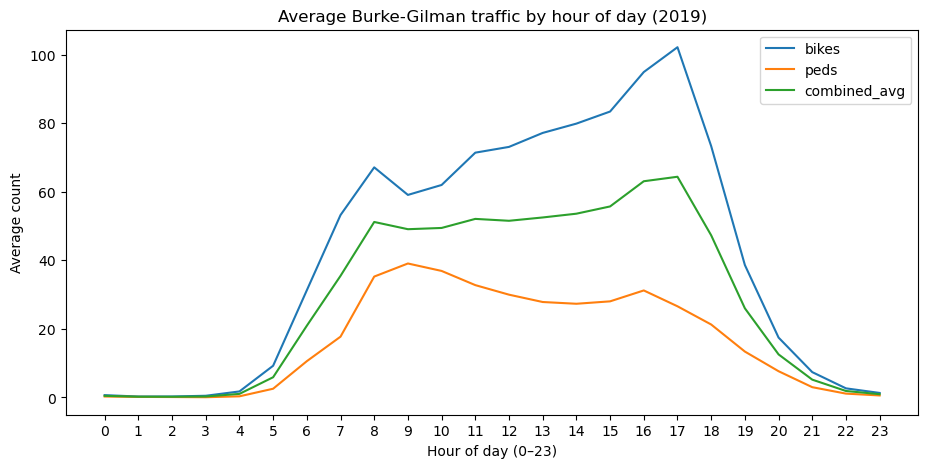

In [46]:
# Your code for Q2
# average bikes and peds for each hour of the day

# which hour has the highest average for each
peak_hours = avg_by_hour.idxmax()
peak_values = avg_by_hour.max()

print("Peak hour for bikes:", peak_hours["bikes"], "with an average of", round(peak_values["bikes"], 1))
print("Peak hour for peds:", peak_hours["peds"], "with an average of", round(peak_values["peds"], 1))

min_hours = avg_by_hour.idxmin()
min_values = avg_by_hour.min()

print("Quietest hour for bikes:", min_hours["bikes"], "with an average of", round(min_values["bikes"], 1))
print("Quitest hour for peds:", min_hours["peds"], "with an average of", round(min_values["peds"], 1))

# plot the averages
avg_by_hour.plot(figsize=(11, 5))
plt.title("Average Burke-Gilman traffic by hour of day (2019)")
plt.xlabel("Hour of day (0–23)")
plt.ylabel("Average count")
plt.xticks(range(0, 24))
plt.show()

**Your Q2 answer:**

*Their patterns do differ. Their quietest times are similar, only a couple of hours off. However, they both peak at very different times. Pedestrians tend to use the trail in the mornings much more than they do in the evenings, whereas cyclists seem to use the trail a lot more in the evenings. My hypothesis for this is that pedestrians choose another form of transportation to return home. Cyclists don't have that luxury because they have a bike to bring back home, so they all return on the bike after work, in the evening*

**Q3. Commuting or recreation?**
Is there evidence people use the Burke-Gilman to *commute*, not just for fun? Compare **weekdays vs. weekends** (we made a `weekday` column for you), and maybe morning vs. evening. Define what a "commuting pattern" would look like in the data, then say whether you see it.

*Hint: `df.groupby("weekday")[["bikes","peds"]].sum()` gets you started. Weekends and weekdays will look different if commuting is real.*

**AI USE**

Used Claude to generate the code with the following prompts

1) i want it split in two groups: weekday and weekends. then give me the hourly averages for both charted like before
This gave information on both the bikes and peds separately. We did not want that.
2) can I just plot the average between bikes and peds?
This gave the correct chart. We did not need to make any changes.
  

Weekday peak hour: 17 with an average of 69.2
Weekend peak hour: 11 with an average of 95.8


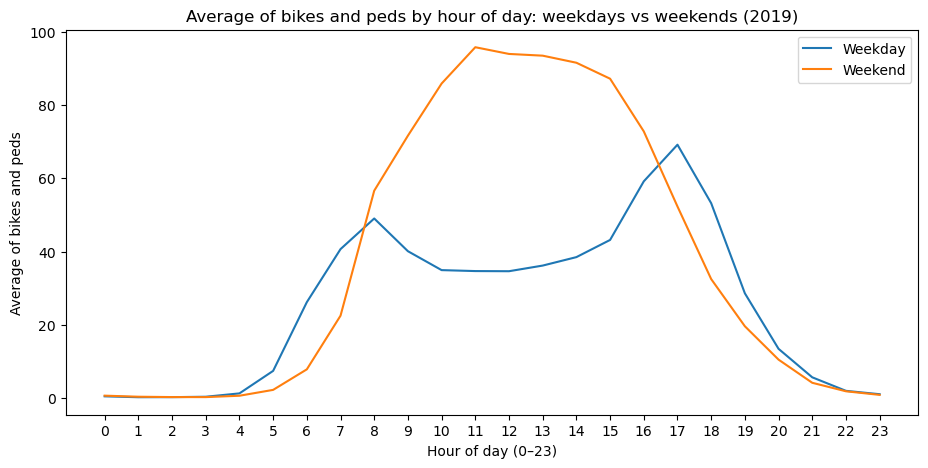

In [36]:
# label each row as Weekday or Weekend
weekend_days = ["Saturday", "Sunday", 5, 6]
df["day_type"] = df["weekday"].apply(lambda d: "Weekend" if d in weekend_days else "Weekday")

# average of bikes and peds for each row
df["combined_avg"] = (df["bikes"] + df["peds"]) / 2

# hourly averages for each group
avg_by_hour = df.groupby(["hour", "day_type"])["combined_avg"].mean().unstack()

# peak hours
for day_type in ["Weekday", "Weekend"]:
    print(f"{day_type} peak hour: {avg_by_hour[day_type].idxmax()} with an average of {round(avg_by_hour[day_type].max(), 1)}")

# plot
avg_by_hour.plot(figsize=(11, 5))
plt.title("Average of bikes and peds by hour of day: weekdays vs weekends (2019)")
plt.xlabel("Hour of day (0–23)")
plt.ylabel("Average of bikes and peds")
plt.xticks(range(0, 24))
plt.legend(title="")
plt.show()

**Your Q3 answer:**

*There is evidence that people use the Burke Gilman to commute because of the peaks times during weekdays (if people are working 9-5 jobs). The weekend does not show this pattern, so it seems that the trail is ALSO used for recreation.*

**Q4. Direction and flow.**
The counter records **north vs. south** separately. Are mornings mostly one direction and evenings the other? What would that tell you about who's using the trail and where they're heading?

**AI USE**

Used claude to generate the code using these prompts

1) now can you do the same as before (combined average charted against the time) but split it between people going north and people going south?
Claude did not know the actual names of the columns in the chart so I had to edit the doe for that. No changes otherwise.

Northbound peak hour: 8 with an average of 31.0
Southbound peak hour: 17 with an average of 40.6


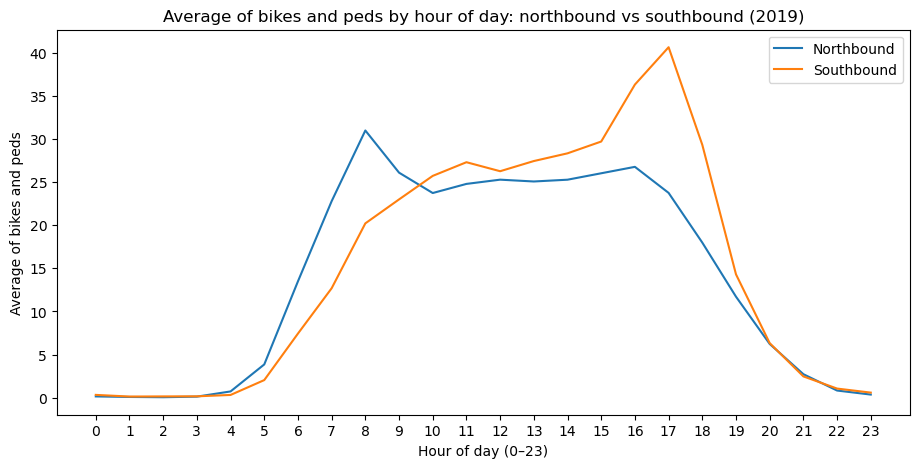

In [38]:
# Your code for Q4
bike_north, bike_south = "bike_north", "bike_south"
ped_north, ped_south = "ped_north", "ped_south"

# average of bikes and peds for each direction, per row
df["north_avg"] = (df[bike_north] + df[ped_north]) / 2
df["south_avg"] = (df[bike_south] + df[ped_south]) / 2

# hourly averages
avg_by_hour = df.groupby("hour")[["north_avg", "south_avg"]].mean()
avg_by_hour.columns = ["Northbound", "Southbound"]

# peak hours
for direction in ["Northbound", "Southbound"]:
    print(f"{direction} peak hour: {avg_by_hour[direction].idxmax()} with an average of {round(avg_by_hour[direction].max(), 1)}")

# plot
avg_by_hour.plot(figsize=(11, 5))
plt.title("Average of bikes and peds by hour of day: northbound vs southbound (2019)")
plt.xlabel("Hour of day (0–23)")
plt.ylabel("Average of bikes and peds")
plt.xticks(range(0, 24))
plt.legend(title="")
plt.show()

**Your Q4 answer:**

*People generally use the Burke to go Northbound in the mornings and Southbound in the evenings, which means people are definitely using this to commute as there seems to be a clear return. However, it's a little interestingto decipher where people are going. If they are going north, it suggests that the Ballard/Fremont area is the start. There's a chance that people are taking the burke gilman north from there to get onto 520 and commute to Bellevue. Otherwise, they would be taking it from the university area to work in the Roosevelt area.*

## Part 3 — Make it reproducible

Good data work can be picked up and re-run by someone else. Two short deliverables:

**1. A `README.md`** in your `A1` folder. Use this template:

```
# A1 — Working with Open Data

**Dataset:** Burke-Gilman Trail counter north of NE 70th St
**Source:** https://data.seattle.gov/Transportation/.../2z5v-ecg8  (pulled YYYY-MM-DD)
**License / terms of use:** <find it on the dataset's page and note it here>

## Questions I asked
- ...

## How to re-run
Open `A1.ipynb` and run all cells (needs `requests`, `pandas`, `matplotlib`).
```

**2. A `LICENSE`** — keep the license file in this folder, and in your README **note the dataset's own license or terms of use** (open datasets almost always have one; find it on the dataset's page). Using open data responsibly means knowing what you're allowed to do with it — that's part of the assignment, not an afterthought.

### One more thing: read the data critically

In 3–4 sentences, name **one limitation or bias** in this dataset and how it could mislead someone who trusted it uncritically.

*(A sensor counts bodies, not intentions. It's one location on a long trail. Some hours may be missing when the counter was offline. A tandem bike counts once. What else?)* This is a warm-up for A2, where finding bias in data is the whole assignment.

**Your answer:**

*(write here)*

## Optional — going further

If you want to push further (not required for full credit):
- Which **day of the week** is busiest? Is it the same for bikes and pedestrians?
- Has the trail gotten **busier over time**? (the data goes back to 2014 — change the year in the query)
- Do fewer people ride when it's **cold or wet**? (join with a Seattle [weather dataset](https://data.seattle.gov/))
- Compare with another counter — the [Fremont Bridge](https://data.seattle.gov/Transportation/Fremont-Bridge-Bicycle-Counter/65db-xm6k) or the [MTS Trail](https://data.seattle.gov/Transportation/MTS-Trail-west-of-I-90-Bridge-Bicycle-and-Pedestri/u38e-ybnc).

## A note on using AI

You may use an LLM (ChatGPT, Claude, …) to help you write code or make a plot. Treat it as a **tool you supervise, not an author you trust**:
- paste the **prompt** you used into a Markdown cell,
- **run** the output and check it against what you expected,
- note **what you changed and why**.

Here, AI is your assistant. In **A3** it becomes your subject of study. Code that runs but that you can't explain won't earn credit — the point is that *you* can ask a question of data and defend the answer.